In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV
import warnings

In [55]:
!pip install xgboost

In [56]:
!pip install catboost

In [57]:
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [58]:
df = pd.read_csv('StudentPerformanceFactors.csv')
df.head(2)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61


Previous_Scores, Motivation_Level, Internet_Access,School_Type,Peer_Influence, Learning_Disabilities,Gender

In [70]:
X = df.drop(['Parental_Involvement','Access_to_Resources','Extracurricular_Activities','Parental_Education_Level','Distance_from_Home','Physical_Activity','Sleep_Hours','Tutoring_Sessions','Family_Income','Teacher_Quality','Exam_Score'], axis=1)
y = df['Exam_Score']

In [71]:
num_features = df.select_dtypes(exclude='object').columns
cat_features = df.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),

    ]
)


In [72]:
df.head(2)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61


In [73]:
X = df.drop('Exam_Score', axis=1)
num_features = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),

    ]
)

X = preprocessor.fit_transform(X)


In [74]:
X

array([[ 0.        ,  1.        ,  0.        , ..., -0.14379993,
        -1.21393446,  0.03141133],
       [ 0.        ,  1.        ,  0.        , ..., -1.1161103 ,
         0.41145109,  1.00119947],
       [ 0.        ,  0.        ,  1.        , ...,  1.1063134 ,
         0.41145109,  1.00119947],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -0.69940585,
         1.22414386, -0.93837681],
       [ 1.        ,  0.        ,  0.        , ...,  1.1063134 ,
         0.41145109,  0.03141133],
       [ 0.        ,  0.        ,  1.        , ...,  1.31466562,
        -1.21393446,  1.00119947]])

In [75]:
X.shape

(6607, 43)

In [76]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)
x_train.shape,x_test.shape

((5285, 43), (1322, 43))

In [77]:
def evaluste_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

In [78]:
model = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "KNN Regressor": KNeighborsRegressor(),
    "Decision Tree Regressor": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),
    "XGB Regressor": XGBRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=False),
    "Adaboost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list = []
for model_name, model_obj in model.items():
    model = model_obj
    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluste_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluste_model(y_test, y_test_pred)

    print(model_name)
    model_list.append(model_name)

    print("Model performance for trining set")
    print("Root mean squared error:{:.4f}".format(model_train_rmse))
    print("Mean absolute error:{:.4f}".format(model_train_mae))
    print("R2 score:{:.4f}".format(model_train_r2))

    print("______________________________")

    print("Model performance for test set")
    print("Root mean squared error:{:.4f}".format(model_test_rmse))
    print("Mean absolute error:{:.4f}".format(model_test_mae))
    print("R2 score:{:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

Linear Regression
Model performance for trining set
Root mean squared error:2.0847
Mean absolute error:0.4982
R2 score:0.7175
______________________________
Model performance for test set
Root mean squared error:1.8034
Mean absolute error:0.4499
R2 score:0.7699
Ridge Regression
Model performance for trining set
Root mean squared error:2.0847
Mean absolute error:0.4982
R2 score:0.7175
______________________________
Model performance for test set
Root mean squared error:1.8033
Mean absolute error:0.4499
R2 score:0.7699
Lasso Regression
Model performance for trining set
Root mean squared error:3.0411
Mean absolute error:1.9606
R2 score:0.3987
______________________________
Model performance for test set
Root mean squared error:2.8196
Mean absolute error:1.9064
R2 score:0.4376
KNN Regressor
Model performance for trining set
Root mean squared error:2.2267
Mean absolute error:1.2483
R2 score:0.6776
______________________________
Model performance for test set
Root mean squared error:2.5376
M

In [79]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model', 'R2 Score'])

,Model,R2 Score
0,Linear Regression,0.769928
1,Ridge Regression,0.769938
2,Lasso Regression,0.437564
3,KNN Regressor,0.544432
4,Decision Tree Regressor,0.191398
5,Random Forest Regressor,0.667119
6,AdaBoost Regressor,-2.005863
7,XGB Regressor,0.669318
8,CatBoost Regressor,0.740857
9,Adaboost Regressor,-0.793371


In [81]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(x_train, y_train)
y_pred = lin_model.predict(x_test)
print("R2 Score:", r2_score(y_test, y_pred)*100, "%")

R2 Score: 76.99282240123634 %


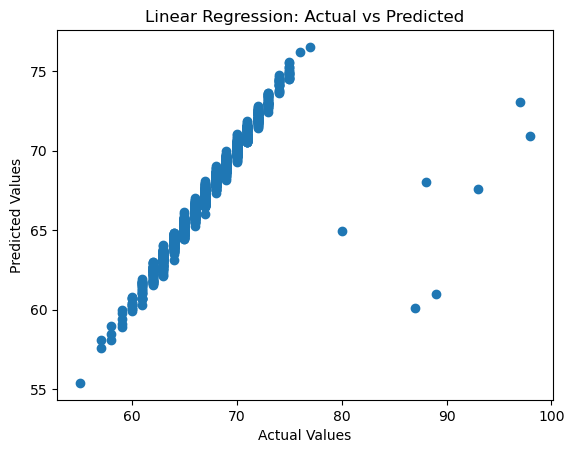

In [82]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [84]:
pred_df = pd.DataFrame({'Actual values': y_test, 'Predicted values': y_pred, 'Difference': y_test - y_pred})
pred_df

,Actual values,Predicted values,Difference
743,65,64.530589,0.469411
5551,65,65.261374,-0.261374
3442,71,71.536378,-0.536378
6571,64,64.268992,-0.268992
4204,66,66.524996,-0.524996
...,...,...,...
4709,69,68.751337,0.248663
3664,72,72.439865,-0.439865
5231,66,66.170614,-0.170614
1773,63,63.415111,-0.415111
